# Análisis Bivariado

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

#Carga del dataset desde archivo local
df = pd.read_csv('../02_limpieza/penguins_limpio.csv')

- Relación: masa corporal / especie
- Relación: especie / isla
- Relación entre tamaño de pico y masa corporal
- Diferencias morfológicas

### Estudio de masa corporal de cada una de las especies

In [6]:
# Estadísticos por grupo
df.groupby('Species')['Body Mass (g)'].agg(['mean', 'median', 'std'])

,mean,median,std
Species,,,
Adelie Penguin (Pygoscelis adeliae),3703.723404,3700.0,460.463045
Chinstrap penguin (Pygoscelis antarctica),3729.850746,3700.0,386.300411
Gentoo penguin (Pygoscelis papua),5074.590164,5000.0,505.945882


In [8]:
# Prueba estadística (ANOVA)
from scipy.stats import f_oneway
grupos = [df[df['Species'] == cat]['Body Mass (g)'] for cat in df['Species'].unique()]
f_stat, p_value = f_oneway(*grupos)
print(f"P-value: {p_value:.4f}")

P-value: 0.0000


El p-value nos indica que existe una relación entre la masa corporal y las especies (p-value < 0.05: bajo - resultado estadísticamente significativo) 

### Estudio de relación de especie por isla

In [ ]:
# Tabla cruzada
pd.crosstab(df['Species'], df['Island'])

Island,Biscoe,Dream,Torgersen
Species,,,
Adelie Penguin (Pygoscelis adeliae),44,52,45
Chinstrap penguin (Pygoscelis antarctica),0,67,0
Gentoo penguin (Pygoscelis papua),122,0,0


In [11]:
# Con proporciones
pd.crosstab(df['Species'], df['Island'], normalize='all')

Island,Biscoe,Dream,Torgersen
Species,,,
Adelie Penguin (Pygoscelis adeliae),0.133333,0.157576,0.136364
Chinstrap penguin (Pygoscelis antarctica),0.000000,0.203030,0.000000
Gentoo penguin (Pygoscelis papua),0.369697,0.000000,0.000000


La especie "Adelie Penguin" se encuentra de manera proporcional en las tres islas.    
En cambio, las especies "Chinstrap penguin" y "Gentooo penguin" solo en una isla, detallamos como sigue,
 - "Chinstrap penguin" se encuentra 100% en la isla Dream.
 - "Gentooo penguin" la localizamos 100% en la isla Biscoe.

### Relación entre tamaño de pico y masa corporal

In [12]:
correlation = df['Culmen Length (mm)'].corr(df['Body Mass (g)'])
print(f"Correlación: {correlation:.2f}")

Correlación: 0.59


La Correlación tiende a 1, lo que indica que están correlacionadas.

### Diferencias morfológicas por especie

#### Longitud del pico por especie

In [13]:
df.groupby('Species')['Culmen Length (mm)'].agg(['mean', 'median', 'std'])

,mean,median,std
Species,,,
Adelie Penguin (Pygoscelis adeliae),38.801418,38.80,2.697538
Chinstrap penguin (Pygoscelis antarctica),48.788060,49.50,3.342904
Gentoo penguin (Pygoscelis papua),47.506557,47.25,3.094510


#### Grosor del pico por especie

In [14]:
df.groupby('Species')['Culmen Depth (mm)'].agg(['mean', 'median', 'std'])

,mean,median,std
Species,,,
Adelie Penguin (Pygoscelis adeliae),18.327660,18.4,1.225917
Chinstrap penguin (Pygoscelis antarctica),18.404478,18.4,1.136106
Gentoo penguin (Pygoscelis papua),14.979508,15.0,0.984839


#### Longitud de las aletas por especie

In [15]:
df.groupby('Species')['Flipper Length (mm)'].agg(['mean', 'median', 'std'])

,mean,median,std
Species,,,
Adelie Penguin (Pygoscelis adeliae),190.290780,190.0,6.479130
Chinstrap penguin (Pygoscelis antarctica),195.671642,196.0,7.074041
Gentoo penguin (Pygoscelis papua),217.147541,216.0,6.496881


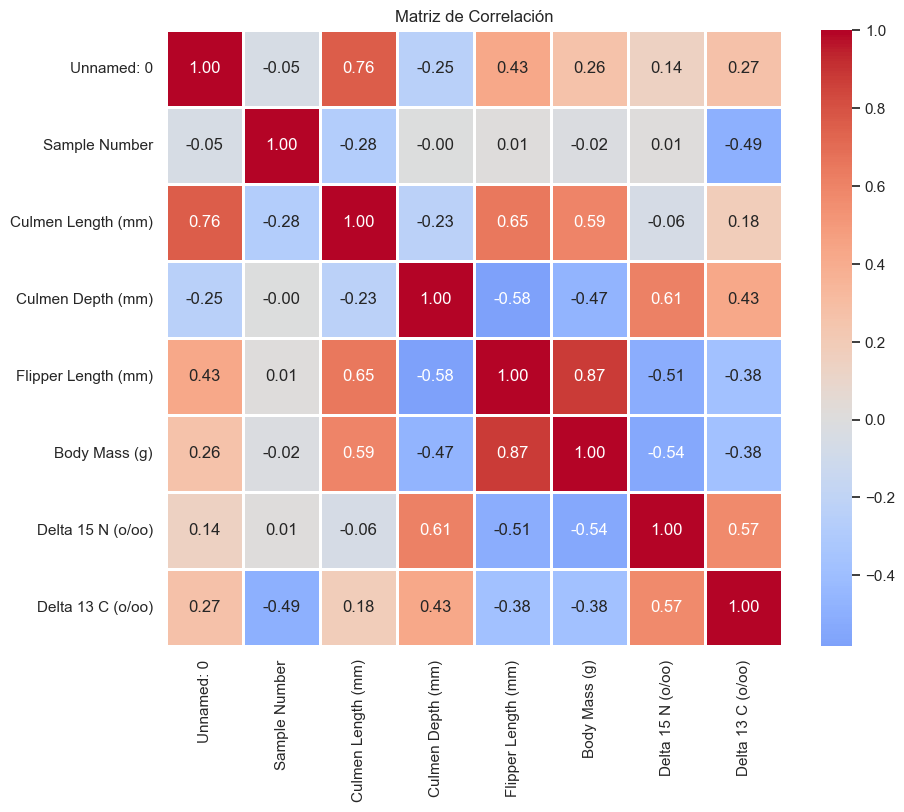

In [18]:
import numpy as np
# Solo numéricas
corr = df.select_dtypes(include=[np.number]).corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()